# Inference with a LoRA adapter

Runtime: Colab T4


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HarshaSrirangam/stable-diffusion-rebuilt/blob/main/notebooks/lora_inference.ipynb)

## Environment/Setup

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device) # should be cuda

cuda


In [2]:
# clone repo
!git clone https://github.com/HarshaSrirangam/stable-diffusion-rebuilt.git
%cd stable-diffusion-rebuilt
!git pull

fatal: destination path 'stable-diffusion-rebuilt' already exists and is not an empty directory.
/content/stable-diffusion-rebuilt
Already up to date.


In [3]:
# install dependencies (skip torch/numpy to avoid overwriting Colab's preinstalled packages)
%pip install -e . --no-deps -q
%pip install transformers safetensors tqdm accelerate pyyaml datasets -q
import sys
sys.path.insert(0, "/content/stable-diffusion-rebuilt/src")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for stable-diffusion-rebuilt (pyproject.toml) ... done


In [4]:
# mount drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# add symlink from colab runs/ -> content/drive/MyDrive/sd-rebuilt/runs/
# runs/ is gitignored and Colab's disk is wiped when the kernel disconnects, so 
# `runs/` is symlinked to a Google Drive folder, which 
# is used to load LoRA checkpoints
!ln -s /content/drive/MyDrive/sd-rebuilt/runs/ runs
!ls -la runs/

total 9
drwx------ 2 root root 4096 Jul 13 07:09 naruto_r16_selfcross_lora
drwx------ 2 root root 4096 Jul 10 22:40 naruto_r16_selfcross_lora_test
lrw------- 1 root root   39 Jul 14 08:20 runs -> /content/drive/MyDrive/sd-rebuilt/runs/


In [6]:
# download SD1.5 checkpoint from HF
#!python scripts/download_data.py

# if HF requests are slow
!mkdir -p /content/stable-diffusion-rebuilt/data/weights
!cp "/content/drive/MyDrive/sd-rebuilt/data/weights/v1-5-pruned-emaonly.safetensors" "/content/stable-diffusion-rebuilt/data/weights/v1-5-pruned-emaonly.safetensors"
!ls -lh data/weights/   # should be ~4.0 GB

total 4.0G
-rw------- 1 root root 4.0G Jul 15 01:09 v1-5-pruned-emaonly.safetensors


## Inference

In [7]:
from transformers import CLIPTokenizer
from sdrebuilt.model.autoencoder import Autoencoder
from sdrebuilt.model.clip import CLIP
from sdrebuilt.model.unet import UNet
from sdrebuilt.convert_weights import load_all
from sdrebuilt.samplers.ddpm import DDPM

# create model, tokenizer, and sampler
vae, clip, unet = Autoencoder().eval(), CLIP().eval(), UNet().eval()
load_all("data/weights/v1-5-pruned-emaonly.safetensors", vae, clip, unet)
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
sampler = DDPM()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [8]:
import yaml
from pathlib import Path
from sdrebuilt.lora.utils import inject_lora

# inject LoRA layers
run_name = "naruto_r16_selfcross_lora"
run_dir = Path("runs") / run_name
training_cfg = yaml.safe_load(open(run_dir / "training_config.yaml"))
inject_lora(
    model=unet,
    target_names=training_cfg["targets"]["layers"],
    r=training_cfg["r"],
    alpha=training_cfg["alpha"]
)

# load LoRA ckpt
checkpoint = "last"
ckpt_dir = run_dir / "checkpoints"
if checkpoint == "last":
    ckpt_path = max(ckpt_dir.glob("checkpoint-*.pt"), key=lambda p: int(p.stem.split("-")[1]))
else:
    ckpt_path = ckpt_dir / f"checkpoint-{checkpoint}.pt"

lora_state = torch.load(ckpt_path)
_ = unet.load_state_dict(lora_state, strict=False)

In [9]:
from sdrebuilt.inference import InferencePipeline

pipeline = InferencePipeline(
    vae=vae,
    clip=clip,
    unet=unet,
    sampler=sampler,
    tokenizer=tokenizer,
    device=device,
    idle_device="cpu"
)

Denoising: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s]


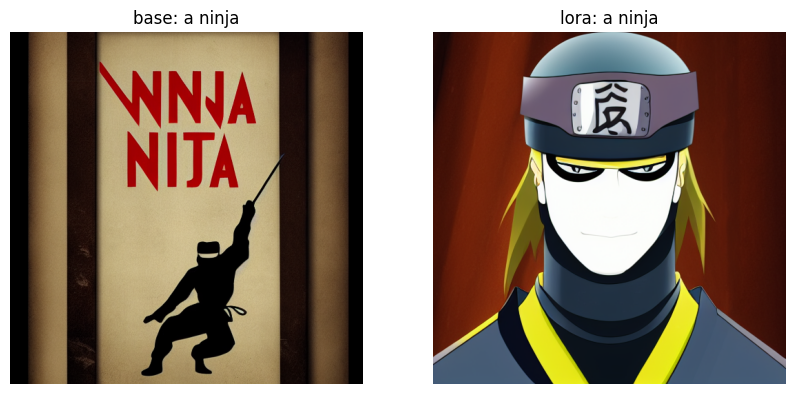

In [10]:
import matplotlib.pyplot as plt
from sdrebuilt.lora.utils import enable_lora, disable_lora

# side-by-side comparison of LoRA vs base model
prompts = ["a ninja"]
seed = 42
pairs = []
for prompt in prompts:
    enable_lora(unet)
    lora_out = pipeline.txt_2_img(prompt=prompt, seed=seed)
    disable_lora(unet)
    base_out = pipeline.txt_2_img(prompt=prompt, seed=seed)
    pairs.append((prompt, lora_out, base_out))

# display outputs
fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 5 * len(pairs)), squeeze=False)
for i, (prompt, lora, base) in enumerate(pairs):
    axes[i, 0].imshow(base)
    axes[i, 0].set_title(f"base: {prompt}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(lora)
    axes[i, 1].set_title(f"lora: {prompt}")
    axes[i, 1].axis("off")
plt.show()